# A SIMT Simulator From Scratch: Watch Your Kernel's Memory Traffic

[CUDA Basics](01_cuda_basics.ipynb) explained the execution model in prose and diagrams. This
chapter makes it executable **without a GPU**: a pure-Python + NumPy simulator
(`src/ai_playground/gpusim/`, ~350 lines) that runs numba.cuda-style kernels and logs **every
memory access** — so instead of being told "strided access is 32x slower," you count the
transactions yourself.

Because it has no native dependencies, this is also the one chapter that can run *anywhere*
Python runs — including Pyodide in a browser.

### Concepts covered

| # | Concept | Section |
|---|---------|---------|
| 1 | Launching kernels: grid, block, thread indexing | §1 |
| 2 | How barriers force the generator design | §2 |
| 3 | Barrier divergence — a real bug class, caught | §3 |
| 4 | Coalescing, visualized per warp | §4 |
| 5 | Shared-memory bank conflicts | §5 |
| 6 | Tiled matmul: why shared memory cuts global traffic ~TILE× | §6 |

::: {.callout-tip title="📺 Video companion"}
[How CUDA Programming Works (Stephen Jones, GTC 2022)](https://www.youtube.com/watch?v=QQceTDjA4f4)
explains the hardware behavior this simulator makes countable — memory transactions, warps,
banks — more in [Videos](../../docs/VIDEOS.md).
:::

<a href="https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/05_gpu_nvidia_tools/01b_simt_simulator.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

No GPU needed anywhere in this notebook — the simulator is pure Python + NumPy.

In [1]:
#| code-fold: true
#| code-summary: "Setup"
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

%config InlineBackend.figure_format = 'retina'
from ai_playground.plotting import apply_plot_style
apply_plot_style()

## 1. The simulator in sixty seconds

A kernel is a function taking `ctx` (this thread's identity: `threadIdx`, `blockIdx`,
`blockDim`, `gridDim`) plus your arrays. Launch syntax mirrors CUDA's `<<<grid, block>>>`.
The launch returns a `LaunchReport` holding the full access log — real CUDA returns nothing,
but inspecting the traffic is the whole point of simulating.

In [2]:
import numpy as np
from ai_playground.gpusim import kernel, coalescing_report, total_transactions

@kernel
def vector_add(ctx, a, b, c):
    i = ctx.grid(1)          # blockIdx.x * blockDim.x + threadIdx.x
    if i < a.size:
        c[i] = a[i] + b[i]

rng = np.random.default_rng(42)
a, b = rng.standard_normal(200).astype(np.float32), rng.standard_normal(200).astype(np.float32)
c = np.zeros(200, dtype=np.float32)

report = vector_add[7, 32](a, b, c)   # 7 blocks x 32 threads = 224 threads for 200 elements

assert np.allclose(c, a + b)
print('correct:', np.allclose(c, a + b))
print(report)

correct: True
<LaunchReport grid=(7, 1, 1) block=(32, 1, 1) threads=224 logged_accesses=600>


The guard `if i < a.size` is the classic CUDA idiom: we launched 224 threads for 200
elements, so the last 24 threads must do nothing. Exactly this kernel — same indexing, same
guard — runs for real in [CUDA Basics §6](01_cuda_basics.ipynb) under Numba.

## 2. Barriers are the hard part — and why kernels become generators

`syncthreads()` means *every* thread in the block reaches the barrier before *any* continues.
So threads must be suspendable mid-kernel. Real GPUs do this in hardware; numba's simulator
uses one OS thread per CUDA thread (impossible in WebAssembly — no threads). Here, kernels
with barriers are **generators**: `yield ctx.syncthreads()` suspends the thread, the scheduler
advances everyone to the barrier, verifies they're at the *same* one, and resumes.

The visible `yield` is honest: it marks exactly where your thread stops and waits.

In [3]:
@kernel
def block_reverse(ctx, x, out):
    """Reverse each block's segment via shared memory — needs one barrier."""
    tile = ctx.shared((32,), np.float32)
    i, t = ctx.grid(1), ctx.threadIdx.x
    tile[t] = x[i]                    # stage into shared memory
    yield ctx.syncthreads()           # everyone's element must land before...
    out[i] = tile[31 - t]             # ...anyone reads a neighbor's slot

x = np.arange(64, dtype=np.float32)
out = np.zeros_like(x)
block_reverse[2, 32](x, out)
print('in :', x[:8], '...')
print('out:', out[:8], '... (each 32-block reversed)')
assert np.allclose(out[:32], x[31::-1]) and np.allclose(out[32:], x[:31:-1])

in : [0. 1. 2. 3. 4. 5. 6. 7.] ...
out: [31. 30. 29. 28. 27. 26. 25. 24.] ... (each 32-block reversed)


## 3. Barrier divergence: the bug the simulator refuses to run

Put a `syncthreads()` where only *some* threads reach it and real hardware gives you undefined
behavior — pre-Volta GPUs simply hang. The simulator turns both variants into loud errors:

In [4]:
from ai_playground.gpusim import BarrierDivergenceError

@kernel
def early_exit(ctx, x):
    if ctx.threadIdx.x == 0:
        return                        # thread 0 leaves...
    x[ctx.threadIdx.x] = 1.0
    yield ctx.syncthreads()           # ...while 31 threads wait for it forever

try:
    early_exit[1, 32](np.zeros(32, dtype=np.float32))
except BarrierDivergenceError as e:
    print('caught:', e)

caught: threads [0] exited while 31 thread(s) wait at a barrier — on real hardware this hangs or is undefined behavior


## 4. Coalescing, finally visible

A warp's 32 loads are serviced in **128-byte transactions**. 32 consecutive fp32 values fit in
exactly one; a stride of 32 elements (128 bytes) puts every lane in its own segment — 32
transactions to deliver the same useful bytes, i.e. ~1/32 of effective bandwidth.

[CUDA Basics §7](01_cuda_basics.ipynb) *measured* this cost on real hardware. Now we *count* it:

In [5]:
from ai_playground.gpusim import plot_warp_accesses

@kernel
def copy_contiguous(ctx, src, dst):
    i = ctx.grid(1)
    dst[i] = src[i]                   # lane k reads element k: one segment

@kernel
def copy_strided(ctx, src, dst):
    i = ctx.grid(1)
    dst[i] = src[32 * i]              # lane k reads element 32k: 32 segments

n = 32
src = np.zeros(32 * n, dtype=np.float32)
r1 = copy_contiguous[1, n](src, np.zeros(n, dtype=np.float32))
r2 = copy_strided[1, n](src, np.zeros(n, dtype=np.float32))

for name, r in [('contiguous', r1), ('strided', r2)]:
    reads = [g for g in coalescing_report(r.log) if g.array == 'src']
    print(f'{name:11s}: {reads[0].transactions:2d} transactions '
          f'(ideal {reads[0].ideal}) for one warp read')

contiguous :  1 transactions (ideal 1) for one warp read
strided    : 32 transactions (ideal 1) for one warp read


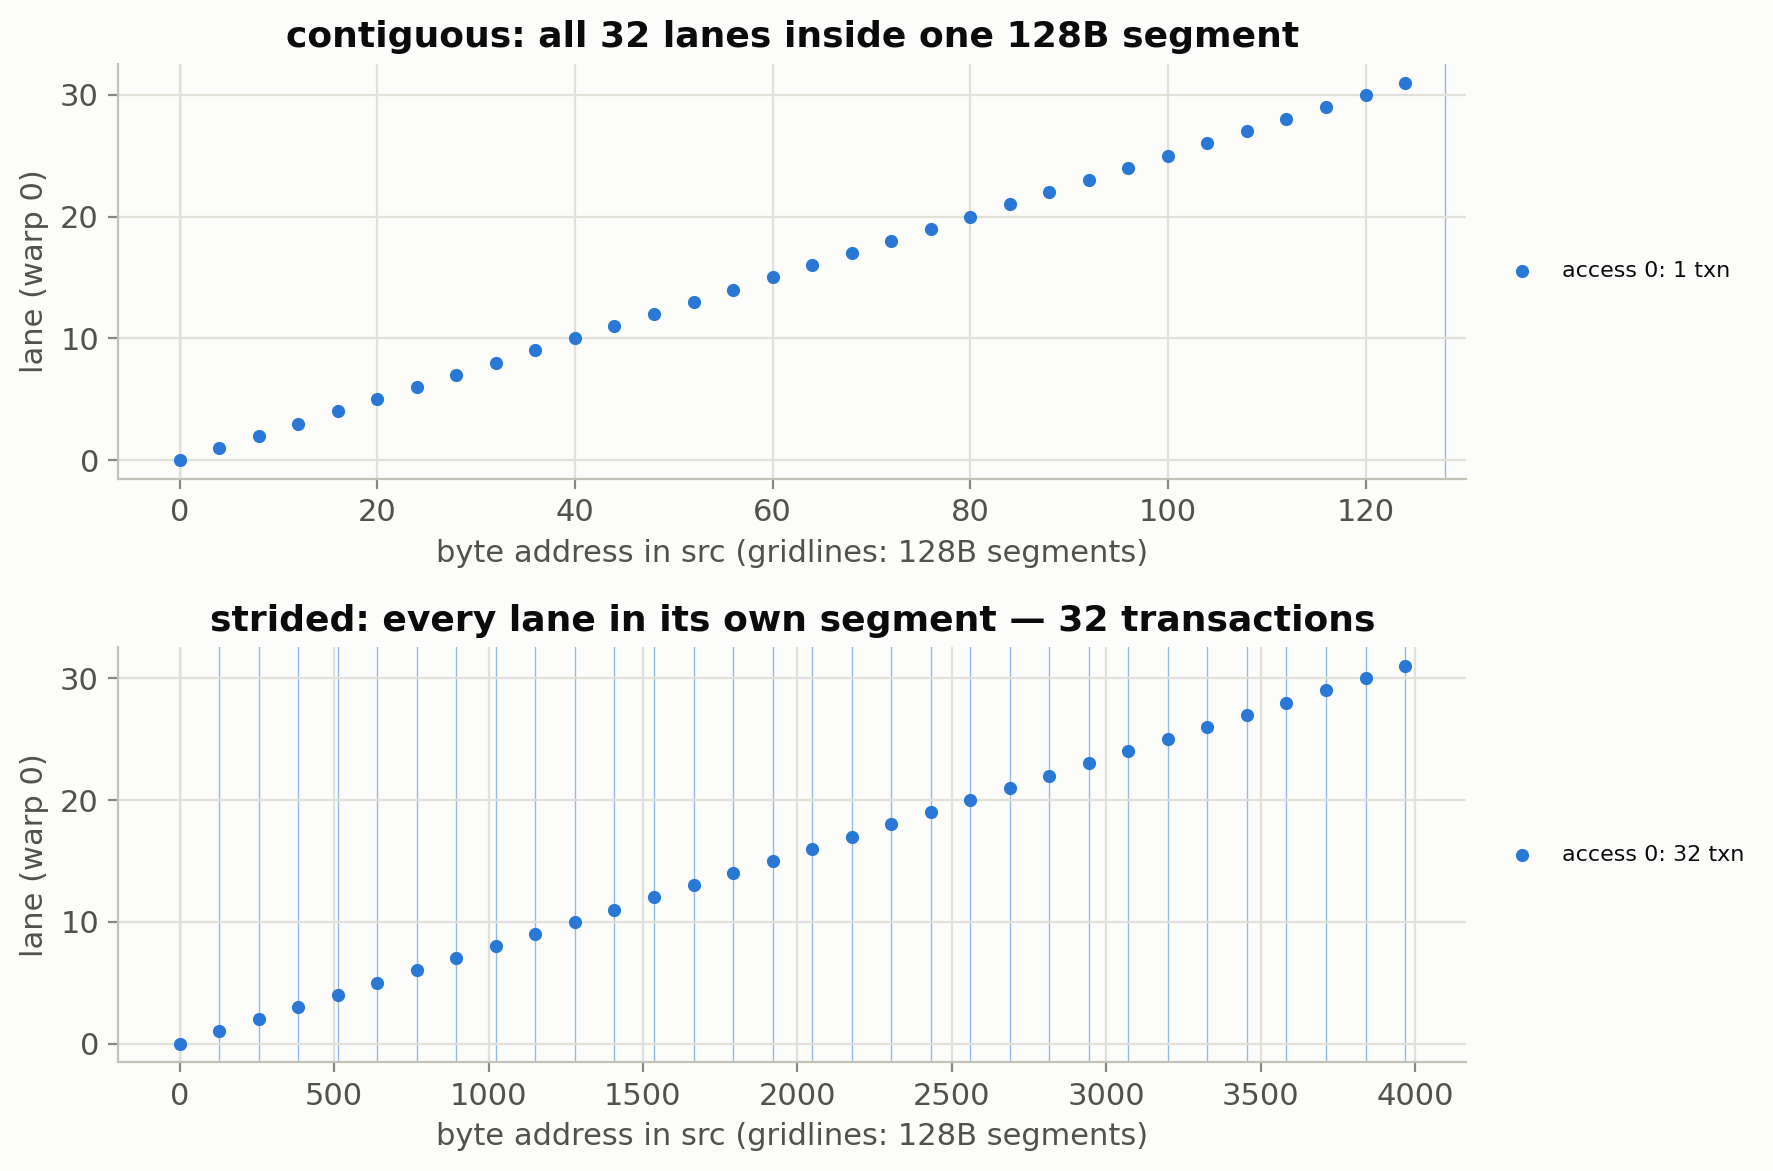

In [6]:
#| code-fold: true
#| code-summary: "Show plotting code"
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 6))
plot_warp_accesses(r1.log, 'src', ax=axes[0])
axes[0].set_title('contiguous: all 32 lanes inside one 128B segment')
plot_warp_accesses(r2.log, 'src', ax=axes[1])
axes[1].set_title('strided: every lane in its own segment — 32 transactions')
plt.tight_layout()
plt.show()

Same 32 elements delivered, 32x the memory transactions. This is takeaway #6 from CUDA
Basics — *"coalesce or die"* — as an actual count rather than a slogan.

## 5. Shared-memory bank conflicts

Shared memory has **32 banks of 4 bytes**. Lanes hitting *distinct addresses in the same bank*
serialize; lanes reading the *same* address broadcast for free. A stride-2 fp32 access maps two
lanes to each bank — a 2-way conflict, half the shared-memory bandwidth:

In [7]:
from ai_playground.gpusim import bank_conflict_report

@kernel
def shared_strides(ctx, out):
    s = ctx.shared((64,), np.float32)
    lane = ctx.threadIdx.x
    s[lane] = float(lane)             # write, stride 1: conflict-free
    yield ctx.syncthreads()
    out[lane] = s[(2 * lane) % 64]    # read, stride 2: 2-way conflict

report = shared_strides[1, 32](np.zeros(32, dtype=np.float32))
for g in bank_conflict_report(report.log):
    label = 'conflict-free' if g.transactions == 1 else f'{g.transactions}-way conflict'
    print(f'{g.array} {g.kind}: {label}')

shared0 w: conflict-free
shared0 r: 2-way conflict


## 6. The payoff: tiled matmul cuts global traffic by TILE×

The naive matmul reads every element of `A` and `B` **n times** — once per output element that
needs it. The tiled version stages TILE×TILE blocks through shared memory so each global element
is read only **n/TILE times**. This reuse — not raw FLOPs — is why every fast matmul (and
FlashAttention) is built around shared memory. Count it:

In [8]:
TILE = 8

@kernel
def naive_matmul(ctx, A, B, C):
    col, row = ctx.grid(2)
    if row < C.shape[0] and col < C.shape[1]:
        acc = 0.0
        for k in range(A.shape[1]):
            acc += A[row, k] * B[k, col]
        C[row, col] = acc

@kernel
def tiled_matmul(ctx, A, B, C):
    tile_a = ctx.shared((TILE, TILE))
    tile_b = ctx.shared((TILE, TILE))
    tx, ty = ctx.threadIdx.x, ctx.threadIdx.y
    col = ctx.blockIdx.x * TILE + tx
    row = ctx.blockIdx.y * TILE + ty
    acc = 0.0
    for k0 in range(0, A.shape[1], TILE):
        tile_a[ty, tx] = A[row, k0 + tx]      # each global element loaded once per tile
        tile_b[ty, tx] = B[k0 + ty, col]
        yield ctx.syncthreads()               # tiles fully staged...
        for k in range(TILE):
            acc += tile_a[ty, k] * tile_b[k, tx]   # ...then TILE reuses from shared
        yield ctx.syncthreads()               # done reading before next overwrite
    C[row, col] = acc

n = 32
A = rng.standard_normal((n, n)).astype(np.float32)
B = rng.standard_normal((n, n)).astype(np.float32)

C1 = np.zeros((n, n), dtype=np.float32)
r_naive = naive_matmul[(n // TILE, n // TILE), (TILE, TILE)](A, B, C1)

C2 = np.zeros((n, n), dtype=np.float32)
r_tiled = tiled_matmul[(n // TILE, n // TILE), (TILE, TILE)](A, B, C2)

assert np.allclose(C1, A @ B, rtol=1e-4) and np.allclose(C2, A @ B, rtol=1e-4)

t_naive, _ = total_transactions(coalescing_report(r_naive.log))
t_tiled, _ = total_transactions(coalescing_report(r_tiled.log))
print(f'both correct. global memory transactions: naive={t_naive}, tiled={t_tiled}')
print(f'tiling cut global traffic {t_naive / t_tiled:.1f}x  (theory: ~TILE = {TILE}x)')

both correct. global memory transactions: naive=5248, tiled=1152
tiling cut global traffic 4.6x  (theory: ~TILE = 8x)


::: {.callout-note title="🏗️ Project milestone M10 — the paged gather, on the simulator"}
M13's engine reads KV through a block table. Write that access pattern as a simulator kernel:
`paged_gather(ctx, pool, table, out)` where each thread copies one element of one token-row
from its physical block into contiguous output. Verify against `np` fancy-indexing, then run
`coalescing_report`: is reading through a block table coalesced? (It should be — tokens are
contiguous *within* a block, so transactions stay near ideal for 16-token blocks.)

**Accept when**: the kernel matches the reference and you can state the measured
transactions-vs-ideal ratio for your block size. Part of
[The Project: Serve Your Own LLM](../../docs/PROJECT.md).
:::

Tiling cut transactions **4.6x** — real, but short of the 8x the element-count argument
promises. The gap is instructive: in *element* terms the naive kernel does read each value
n times vs n/TILE (the full 8x), but at the *transaction* level it was already getting help —
all 8 lanes sharing a `ty` read the **same** `A[row, k]` address, and a warp services
identical addresses with one broadcast transaction. Counting transactions instead of
accesses is exactly the correction real hardware applies to naive intuition, and it's why
profilers report transactions, not loads. On real hardware this reuse is still the
difference between a bandwidth-bound kernel and a compute-bound one — the
[SGEMM chapter](02_sgemm_optimization.ipynb) plays this same trick with real CUDA and pushes it
to cuBLAS-level performance.

## Key Takeaways

1. **CUDA's model is small enough to build yourself** — grid/block/thread indexing, shared
   memory, and barriers fit in ~200 lines of Python. If you can implement it, you understand it.
2. **Barriers are the essence of block cooperation.** The generator design makes the suspension
   point visible — and barrier divergence becomes a caught error instead of a hung GPU.
3. **Coalescing is countable.** One warp read = 1 transaction if contiguous, up to 32 if
   strided. The simulator's plots show the exact segments each lane touches.
4. **Shared memory is a *reuse* mechanism, not a cache.** Tiling cut global transactions 4.6x here (and
   element reads by the full TILE=8x) while producing identical results — the insight behind fast GEMMs and FlashAttention
   ([Dao et al., 2022](https://arxiv.org/abs/2205.14135)).
5. **Semantics simulate; performance doesn't.** The simulator counts what hardware *would* do —
   for real timings, open [CUDA Basics](01_cuda_basics.ipynb) or the
   [SGEMM chapter](02_sgemm_optimization.ipynb) on a GPU.
6. **Pure Python + NumPy means it runs anywhere** — including Pyodide in a browser tab, where
   real CUDA (and even Numba's own simulator, which needs llvmlite) cannot go.

### What to read next

- Next: [`01c_virtual_gpu.ipynb`](01c_virtual_gpu.ipynb) — the same kernels on a cycle-approximate virtual T4, with the die animated.
- Then: [`02_sgemm_optimization.ipynb`](02_sgemm_optimization.ipynb) — the tiling idea
  from §6, on real hardware, optimized until it rivals cuBLAS.
- The simulator source: `src/ai_playground/gpusim/` (`core.py` for the scheduler,
  `memory.py` for the transaction math) — and `tests/test_gpusim.py` for its contract.
